In [4]:
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import pandas as pd

In [2]:
iris = load_iris()

In [9]:
X = iris.data
y = iris.target

In [10]:
X.shape

(150, 4)

<Axes: >

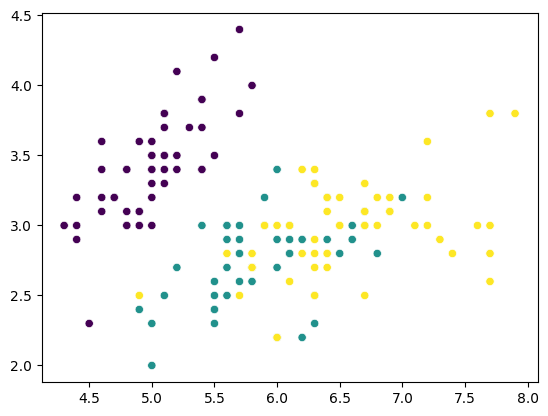

In [16]:
# Visualize
# 4D data so pick any one for visualization
sns.scatterplot(x = X[: , 0] , y = X[: , 1])

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [26]:
# optional - dimensionality reduction using PCA
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)
pca_data = pca.fit_transform(X_scaled)

In [27]:
# Elbow Method

wcss = []

for k in range(1 , 11):
    kmeans = KMeans(n_clusters = k)
    kmeans.fit(pca_data )
    wcss.append(kmeans.inertia_)

<Axes: >

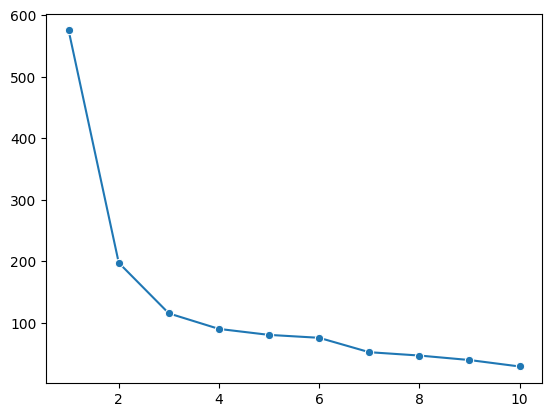

In [28]:
sns.lineplot(x = range(1 , 11) , y = wcss , marker = 'o')

<Axes: >

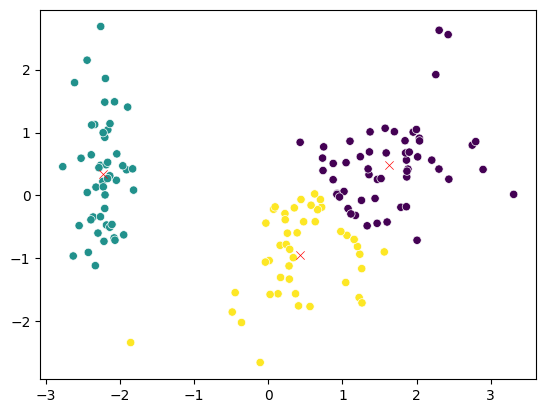

In [32]:
# KMeans

kmeans = KMeans(n_clusters = 3 , random_state = 10)
labels = kmeans.fit_predict(pca_data )
sns.scatterplot(x = pca_data[: , 0] , y = pca_data[: , 1] , c = labels)
sns.scatterplot(x = kmeans.cluster_centers_[: , 0] , y = kmeans.cluster_centers_[: , 1] , marker = "x" , c = "red")